In [3]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./dim5/"
for file in os.listdir(DIR)[:1]:
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

"""
PKLs = []

for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR+file, "rb"))
        loaded =  {'res': (None, None, None, loaded['res'][3], None, loaded['res'][5], loaded['res'][6], None, loaded['res'][8]), 'config':loaded['config']}
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False"""

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


'\nPKLs = []\n\nfor file in os.listdir(DIR):\n    if file.endswith(".pkl") and "merge" not in file:\n        loaded = pickle.load(open(DIR+file, "rb"))\n        loaded =  {\'res\': (None, None, None, loaded[\'res\'][3], None, loaded[\'res\'][5], loaded[\'res\'][6], None, loaded[\'res\'][8]), \'config\':loaded[\'config\']}\n        PKLs.append(loaded)\n        PKL_titles.append(str(file))\nn = len(PKLs)\nplt.rcParams[\'text.usetex\'] = False'

In [16]:
np.var(PKLs[0]['res'][0][0, 0, 0, ..., 1].reshape(-1))

Array(0.99751234, dtype=float32)

In [3]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

In [4]:
for proposal in idx_proposal:
    concat_temp = jnp.concat([PKLs[idx]['res'][6] for idx in idx_proposal[proposal]])
    concat_lg_norm = jnp.concat([PKLs[idx]['res'][8] for idx in idx_proposal[proposal]])
    res = {'res': (None, None, None, None, None, None, concat_temp, None, concat_lg_norm), 'config': PKLs[idx_proposal[proposal][0]]['config']}
    with open(DIR+proposal+"_merge.pkl", "wb") as handle:
        pickle.dump(res, handle, protocol=pickle.HIGHEST_PROTOCOL)

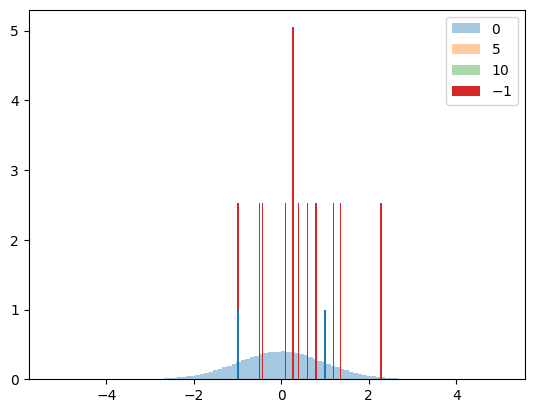

In [5]:
idx=0
for t in np.concatenate([np.arange(0, PKLs[idx]['res'][0].shape[1], 5), [-1]]):
    if t == -1:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=1, density=True, label=rf"${-1}$")
    else:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=0.4, density=True, label=rf"${t}$")
plt.legend()
plt.vlines(x=1, ymin=0, ymax=1)
plt.vlines(x=-1, ymin=0, ymax=1)

In [7]:
#%%
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def plot_3D(x, y, arr):
    # Assume arr is your n x n array
    X, Y = np.meshgrid(x, y)
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the surface
    ax.plot_surface(X, Y, arr, cmap='viridis')  # you can change the colormap
    ax.set_xlabel(r'$\rho$ axis')
    ax.set_ylabel(r'$\tau$ axis')
    ax.set_zlabel('Z axis (array values)')
    ax.view_init(elev=30, azim=135)
    
    plt.show()

def plot_contour2D(x, y, arr):
    X, Y = np.meshgrid(x, y)
    
    plt.figure()
    cf = plt.contourf(X, Y, arr, levels=20, cmap='viridis')
    plt.xlabel(r'$\tau$ axis')
    plt.ylabel(r'$\rho$ axis')
    plt.colorbar(cf)  # Show color scale
    plt.show()


    

In [8]:

tau_grid = jnp.linspace(0.05, 4, 100)
rho_grid = jnp.linspace(0, 0.99, 100)

idx = idx_proposal["build_build_uncoupled_autoregressive_gaussian_proposal"][0]
t = PKLs[idx]['res'][5].shape[1]
vals = np.array([PKLs[idx]['res'][5].mean(axis=0).reshape((t, rho_grid.shape[-1], tau_grid.shape[-1])) for idx in idx_proposal["build_build_uncoupled_autoregressive_gaussian_proposal"]]).mean(axis=0)
for t in np.arange(0, vals.shape[0], 4):
    print(PKLs[idx]['res'][6][:,t].mean())
    arr = vals[t]
    plot_contour2D(tau_grid, rho_grid,arr)
    plt.clf()

KeyError: 'build_build_uncoupled_autoregressive_gaussian_proposal'

In [ ]:
PKLs[0]['res'][3]

In [ ]:
import jax
import jax.numpy as jnp
optimal_parameters = jnp.array([PKLs[idx]['res'][3] for idx in idx_proposal['build_build_uncoupled_autoregressive_gaussian_proposal']])
optimal_parameters = optimal_parameters.reshape((-1, *optimal_parameters.shape[2:]))
optimal_parameters = jnp.swapaxes(jnp.swapaxes(optimal_parameters, axis1=0, axis2=1), 1, -1)
optimal_parameters_std = jax.vmap(lambda x: jnp.diag(x))(jax.vmap(lambda x: jnp.cov(x, rowvar=True))(optimal_parameters))**0.5
param_idx = 0
plt.errorbar(x=np.arange(1, 16), y=optimal_parameters.mean(axis=-1)[:,param_idx], yerr=optimal_parameters_std[:,param_idx], label=r"$\rho$")
param_idx = 1
plt.errorbar(x=np.arange(1, 16), y=optimal_parameters.mean(axis=-1)[:,param_idx], yerr=optimal_parameters_std[:,param_idx], label=r"$\tau$")
mean_temperatures = jnp.array([PKLs[idx]['res'][6].mean(axis=0) for idx in idx_proposal['build_build_uncoupled_autoregressive_gaussian_proposal']]).mean(axis=0)
#plt.plot(np.diff(mean_temperatures))
plt.xlabel(r"Iteration $t$")
plt.legend()


In [ ]:
mean_temperatures = {proposal: jnp.array([PKLs[idx]['res'][6].mean(axis=0) for idx in idx_proposal[proposal]]).mean(axis=0)
                     for proposal in idx_proposal}


In [ ]:
for proposal in idx_proposal:
    plt.plot(mean_temperatures[proposal], label=proposal)
plt.legend()

In [ ]:
x, y = np.meshgrid(rho_grid, tau_grid)

In [ ]:
rho_grid = jnp.linspace(0, 0.99, 50)
tau_grid = jnp.linspace(0.1, 1, 50)
params_grid = jnp.array([[x, y] for x in rho_grid for y in tau_grid])

In [ ]:
idx_proposal

In [ ]:
def slice_esjd(idx=0, slic=-1, axis=0):
    grid = tau_grid if axis==1 else rho_grid
    opposite_grid = tau_grid if axis==0 else rho_grid
    t = PKLs[idx]['res'][5].shape[1]
    vals = PKLs[idx]['res'][5].mean(axis=0)
    vals = vals.reshape((t, rho_grid.shape[0], tau_grid.shape[0]))
    dim = PKLs[idx]['res'][0].shape[-1]
    for t in np.arange(0, vals.shape[0], 1):
        my_slice = vals[t, :, slic] if axis==0 else vals[t, slic, :]
        lmbd = PKLs[idx]['res'][6].mean(axis=0)[t]
        plt.plot(grid, my_slice, label=rf"${t}, {lmbd}$", alpha=0.5)
        sigmasq = (0.3**(-1)-1)**(-1)
        if axis==1:
            plt.vlines(x=2.38/np.sqrt(dim) * (lmbd*sigmasq**(-1)+1)**(-1), ymin=0, ymax=1,  linestyle="--", alpha=0.5)
    plt.legend()
    xlabel = r"$\rho$" if axis==0 else r"$\tau$"
    oppositexlabel = r"$\tau$" if axis==0 else r"$\rho$"
    plt.xlabel(xlabel)
    plt.ylabel(r"ESJD, "+oppositexlabel+" = "+str(opposite_grid[slic]))
    plt.show()
    plt.clf()

slice_esjd(1, 0, 0)

In [ ]:
slice_esjd(0, 10, 1)

In [ ]:
def esjd_ar(idx, rho):
    tau = np.sqrt(1-rho**2)
    idx_tau  = np.argmin(np.abs(tau_grid - tau))
    idx_rho = np.argmin(np.abs(rho_grid - rho))
    t = PKLs[idx]['res'][5].shape[1]
    vals = PKLs[idx]['res'][5].mean(axis=0)
    vals = vals.reshape((t, rho_grid.shape[0], tau_grid.shape[0]))
    dim = PKLs[idx]['res'][0].shape[-1]
    return vals[:, idx_rho, idx_tau]
def plot_esjd_ar(idx):
    grid = rho_grid
    esjd_along_the_circle = np.array([esjd_ar(idx, rho) for rho in rho_grid])
    print(esjd_along_the_circle.shape)
    for t in np.arange(0, vals.shape[0], 3):
        my_slice = esjd_along_the_circle[:,t]
        lmbd = PKLs[idx]['res'][6].mean(axis=0)[t]
        plt.plot(grid, my_slice, label=rf"${t}, {lmbd}$", alpha=0.5)
        sigmasq = (0.3**(-1)-1)**(-1)
    plt.legend()
    xlabel = r"$\rho$"
    oppositexlabel = r"$\tau=\sqrt(1-\rho^2)$" 
    plt.xlabel(xlabel)
    plt.ylabel(r"ESJD")
    plt.show()
    plt.clf()
plot_esjd_ar(0)

In [ ]:
def get_hist(idx, dim, t):
    if dim == -1:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=1, density=True, label=rf"${t}$")
    else:
        plt.hist(PKLs[idx]['res'][0][:,t,0,..., dim].reshape(-1), bins=100, alpha=1, density=True, label=rf"${t}$,${dim+1}$")
    plt.legend()
    plt.show()
    plt.clf()
get_hist(2, 0, 0)

In [ ]:
PKLs[idx]['res'][6]

In [4]:
corr_coeff = 0.9
dim = 3
latent_dim = 2

In [13]:
corr = jnp.eye(dim)
corr = corr.at[latent_dim:, ].set(corr_coeff)
corr = corr.at[:, latent_dim:].set(corr_coeff)
c = jnp.sqrt(jnp.diag(corr))
corr = corr / jnp.outer(c,c)

In [14]:
corr

Array([[1.       , 0.       , 0.9486834],
       [0.       , 1.       , 0.9486834],
       [0.9486834, 0.9486834, 1.0000001]], dtype=float32)